<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo_Mexico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Grupo México

#Tendencia
##Medias Móviles

In [149]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_7659/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [150]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [151]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

###Media Móvil Simple

In [153]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

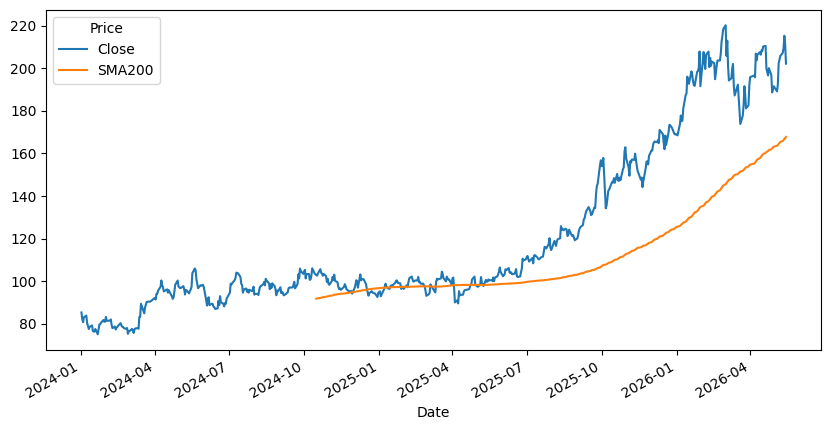

In [154]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [155]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [156]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

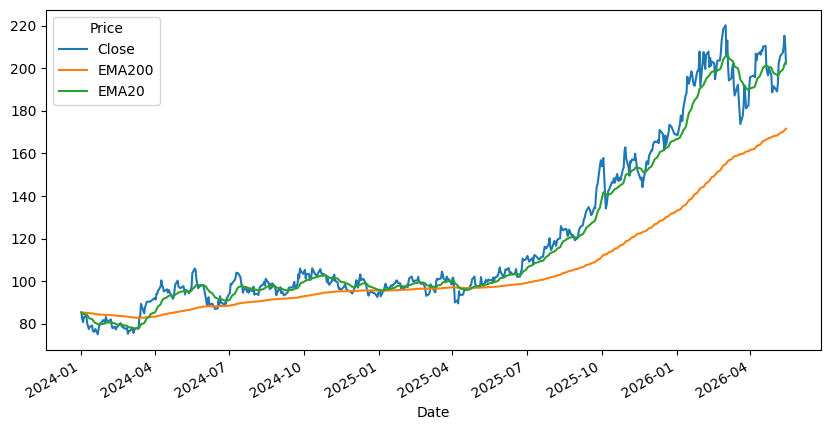

In [157]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

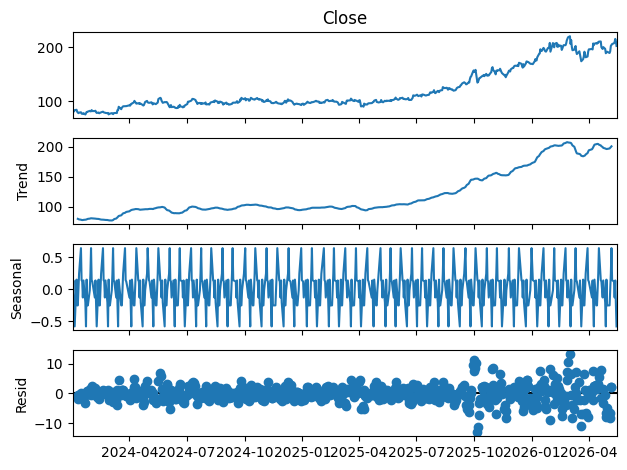

In [158]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

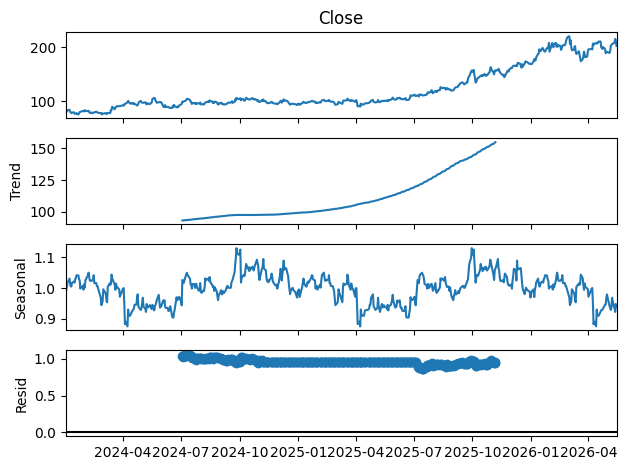

In [159]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

##Serie Estacionaria


In [160]:
#Obtener datos
precios = df['Close']

In [161]:
# Transformación a retornos porcentuales (diferenciación)
# Los precios suelen ser no estacionarios, los retornos sí lo son.
retornos = precios.pct_change().dropna()

In [162]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [163]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.1555
Valor p: 0.9697
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.969651107080283)

In [164]:
# Ejecutar prueba en Retornos (Transformados)
probar_estacionariedad(retornos, "Retornos Porcentuales")


--- Prueba ADF para: Retornos Porcentuales ---
Estadístico de Dickey-Fuller: -26.6131
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

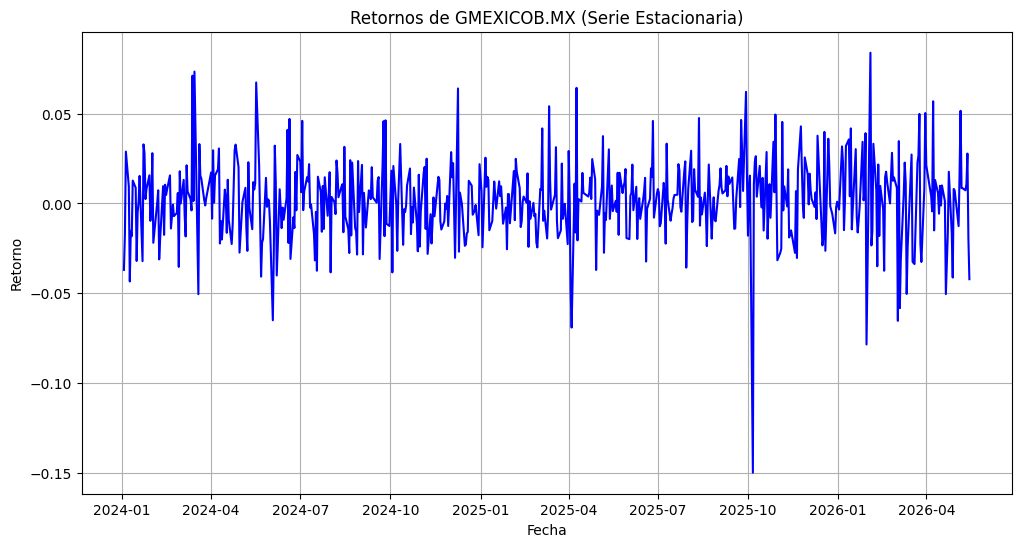

In [165]:
# Visualización
plt.figure(figsize=(12, 6))
plt.plot(retornos, label=f'Retornos de {'GMEXICOB.MX'}', color='blue')
plt.title(f'Retornos de {'GMEXICOB.MX'} (Serie Estacionaria)')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.grid(True)
plt.show()

##Diferenciando para hacer estacionaria la serie

In [166]:
precios = df['Close']

Head of the differenced price series:
Date
2024-01-03   -3.156296
2024-01-04   -1.423080
2024-01-05    2.326164
2024-01-08    0.784531
2024-01-09   -3.639786
Name: Close, dtype: float64


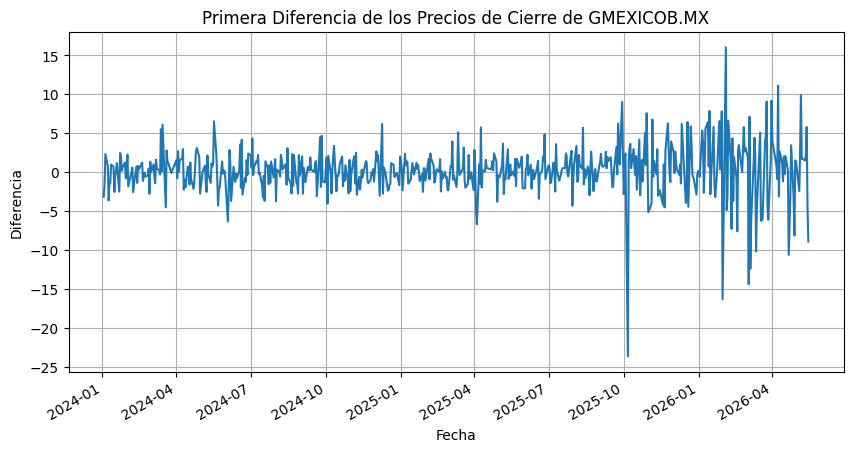

In [167]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

# Mostrar los primeros elementos de la serie diferenciada
print("Head of the differenced price series:")
print(differenced_prices.head())

# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [168]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.8263
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

##Volatilidad

In [169]:
#Obtener datos
precios = df['Close']

In [170]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-05-11    0.007267
2026-05-12    0.010707
2026-05-13    0.027368
2026-05-14   -0.019756
2026-05-15   -0.043095
Name: Rendimientos_Log, Length: 592, dtype: float64


In [173]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-11    0.007267
2026-05-12    0.010707
2026-05-13    0.027368
2026-05-14   -0.019756
2026-05-15   -0.043095
Name: Rendimientos_Log, Length: 591, dtype: float64


In [174]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [175]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [176]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f}")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f}")

Volatilidad diaria: 0.0224
Volatilidad anualizada: 0.3551
